In [ ]:
%pip install timm==0.9.12 torch torchmetrics torchvision --index-url https://download.pytorch.org/whl/cu121 --upgrade tqdm opencv-python pillow --upgrade

In [1]:
import torch
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0)) 

GPU name: NVIDIA GeForce RTX 4060 Ti


In [1]:
# Cell 1 - Imports and Setup
from pathlib import Path
import hashlib, cv2, random
import numpy as np
from PIL import Image
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from tqdm import tqdm
from collections import defaultdict
from torch.utils.data import Dataset, DataLoader
import timm
import torch
import torch.nn as nn
from collections import Counter
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)
from tqdm.auto import tqdm
import numpy as np
import json
import pandas as pd
import warnings
import gc
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths
DATA_ROOT = Path(r"G:/My Drive/CLPD-MF-Dataset")
MODEL_PATH = Path("C:/Users/Mohamed Hazem/Graduation Project/Dr. Rushdy/CLPD Dr. Kariman/Mycosis-Fungoides-Classifier/Trained Models")
OUTPUT_PATH = Path("./5 Class Evaluation Results")
OUTPUT_PATH.mkdir(exist_ok=True)

assert DATA_ROOT.exists(), f"Dataset folder not found at {DATA_ROOT}"
assert MODEL_PATH.exists(), f"Model folder not found at {MODEL_PATH}"

print(f"Dataset root: {DATA_ROOT}")
print(f"Model path: {MODEL_PATH}")
print(f"Output path: {OUTPUT_PATH}")

c:\Users\Mohamed Hazem\anaconda3\envs\dlclass\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Dataset root: G:\My Drive\CLPD-MF-Dataset
Model path: C:\Users\Mohamed Hazem\Graduation Project\Dr. Rushdy\CLPD Dr. Kariman\Mycosis-Fungoides-Classifier\Trained Models
Output path: 5 Class Evaluation Results


In [2]:
# Cell 2
def list_images_and_labels(root):
    """
    List all images with labels and magnifications from the new folder structure.
    Adds a 'target_class' key for 5-way multi-class training.
    """
    rows = []
    root = Path(root)
    
    # Process MF folder
    mf_dir = root / "MF"
    if mf_dir.exists():
        for patient_dir in mf_dir.iterdir():
            if not patient_dir.is_dir(): continue
            
            patient_name = patient_dir.name
            if not (patient_dir / 'x10').exists():
                print(f"Warning: No x10 folder for patient {patient_name} in MF")

            for mag in ['x10', 'x20']:
                mag_dir = patient_dir / mag
                if mag_dir.exists() and mag_dir.is_dir():
                    for img_path in mag_dir.glob('*.tif'):
                        rows.append({
                            'path': img_path,
                            'label': 'MF',
                            'patient': patient_name,
                            'mag': mag,
                            'subtype': 'MF', # Set subtype to MF for consistency
                            'target_class': 'MF' # <--- NEW: Unified class for PyTorch
                        })
    
    # Process Non-MF folder with subtypes
    nonmf_dir = root / "Non-MF"
    if nonmf_dir.exists():
        for subtype_dir in nonmf_dir.iterdir():
            if not subtype_dir.is_dir(): continue
            
            subtype = subtype_dir.name  # B cell Lymphoma, PLEVA-PLC, etc.
            
            for patient_dir in subtype_dir.iterdir():
                if not patient_dir.is_dir(): continue
                
                patient_name = patient_dir.name
                for mag in ['x10', 'x20']:
                    mag_dir = patient_dir / mag
                    if mag_dir.exists() and mag_dir.is_dir():
                        if not any(mag_dir.iterdir()):
                            print(f"Warning: No images found for patient {patient_name} in subtype {subtype} at {mag}")
                        for img_path in mag_dir.glob('*.tif'):
                            rows.append({
                                'path': img_path,
                                'label': 'Non-MF',
                                'patient': patient_name,
                                'mag': mag,
                                'subtype': subtype,
                                'target_class': subtype # <--- NEW: Maps to specific disease
                            })
            
    return rows

# Load all images
print("\n" + "="*80)
print("LOADING DATASET (5-CLASS SETUP)")
print("="*80 + "\n")

all_images = list_images_and_labels(DATA_ROOT)

print(f"Total images found: {len(all_images)}")

print(f"\nLabel distribution (Binary):")
label_counts = Counter([r['label'] for r in all_images])
for label, count in sorted(label_counts.items()):
    print(f"  {label}: {count} images")

print(f"\nTarget Class distribution (Multi-Class):")
target_counts = Counter([r['target_class'] for r in all_images])
for target, count in sorted(target_counts.items()):
    target_patients = len(set(r['patient'] for r in all_images if r['target_class'] == target))
    print(f"  {target}: {count} images ({target_patients} patients)")



LOADING DATASET (5-CLASS SETUP)

Total images found: 6267

Label distribution (Binary):
  MF: 4306 images
  Non-MF: 1961 images

Target Class distribution (Multi-Class):
  B cell Lymphoma: 358 images (18 patients)
  MF: 4306 images (311 patients)
  PLEVA-PLC: 1268 images (108 patients)
  T-cell dyscrasia: 180 images (15 patients)
  pseudolymphoma: 155 images (11 patients)


In [3]:
# Cell 3
PATCH_CACHE = Path('./patch_cache')
PATCH_CACHE.mkdir(exist_ok=True)

def extract_and_cache_patches(
    img_path,
    patch_size=512,
    stride=256,
    min_foreground_ratio=0.285,
    max_patches_per_image=150,
):
    """
    Extract tissue patches from a WSI.  Results are cached under
    PATCH_CACHE / <sha1> / ps<patch_size> / so that different
    patch sizes share the same top-level folder but are kept separate.
    """
    key       = hashlib.sha1(str(img_path).encode()).hexdigest()
    cache_dir = PATCH_CACHE / key / f"ps{patch_size}"

    if cache_dir.exists() and any(cache_dir.iterdir()):
        return sorted(str(p) for p in cache_dir.glob('*.jpg'))

    cache_dir.mkdir(parents=True, exist_ok=True)
    patches = []

    # CRITICAL FIX: Use 'with' so Windows forcefully closes the file handle immediately
    with Image.open(img_path) as img:
        W, H  = img.size

        for y in range(0, H - patch_size + 1, stride):
            for x in range(0, W - patch_size + 1, stride):
                # CRITICAL FIX: Crop FIRST, then convert only the tiny patch to RGB
                crop = img.crop((x, y, x + patch_size, y + patch_size))
                crop_rgb = crop.convert('RGB')
                
                arr  = np.asarray(crop_rgb)
                hsv  = cv2.cvtColor(arr, cv2.COLOR_RGB2HSV)
                
                if (hsv[:, :, 1] > 20).mean() < min_foreground_ratio:
                    continue
                
                fname = cache_dir / f"{x}_{y}.jpg"
                crop_rgb.save(fname, quality=90)
                patches.append(str(fname))
                
                if len(patches) >= max_patches_per_image:
                    break
            if len(patches) >= max_patches_per_image:
                break

    gc.collect()
    return patches

In [4]:
# Cell 4
class MFHistologyDataset(Dataset):
        def __init__(self, rows, mag='x20', mode='train', patching=True, patch_size=512,
                     stride=256, transforms=None, max_patches_per_image=100):
            self.rows = [r for r in rows if (mag is None or r['mag']==mag)]
            self.mode = mode
            self.patching = patching
            self.patch_size = patch_size
            self.stride = stride
            self.max_patches_per_image = max_patches_per_image
            self.transforms = transforms
            
            # --- MODIFICATION 1: Use target_class instead of label ---
            labels = sorted(list({r['target_class'] for r in self.rows}))
            self.label2idx = {lab:i for i,lab in enumerate(labels)}
            # Save the reverse mapping so you know which index is which disease later
            self.idx2label = {i:lab for lab,i in self.label2idx.items()} 

            self.items = []
            for i, r in enumerate(self.rows):
                if self.patching:
                    patches = extract_and_cache_patches(r['path'], patch_size=self.patch_size,
                                                        stride=self.stride, max_patches_per_image=self.max_patches_per_image)
                    for p in patches:
                        # --- MODIFICATION 2: Save the target_class index ---
                        self.items.append({'img': p, 'label': self.label2idx[r['target_class']], 'source': str(r['path'])})
                    
                    del patches
                    gc.collect()
                else:
                    self.items.append({'img': str(r['path']), 'label': self.label2idx[r['target_class']], 'source': str(r['path'])})
                    
            if len(self.items)==0:
                print("Warning: dataset empty for magnification", mag)

        def __len__(self): return len(self.items)

        def __getitem__(self, idx):
            it = self.items[idx]
            img = Image.open(it['img']).convert('RGB')
            if self.transforms: img = self.transforms(img)
            return img, it['label'], it['source']


train_tf = transforms.Compose([
    transforms.Resize((512,512), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15), 
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((512,512), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])


In [5]:
# Cell 5
def patient_split_stratified(rows, mag='x20', val_frac=0.15, seed=40):

    # group patients by class
    cls_map = {}
    for r in rows:
        if mag is not None and r['mag'] != mag: continue
        cls_map.setdefault(r['target_class'], {}).setdefault(r['patient'], []).append(r)

    # Now stratify
    train_rows, val_rows = [], []
    rng = random.Random(seed)

    for cls, patients_dict in cls_map.items():
        patients = list(patients_dict.keys())
        rng.shuffle(patients)

        n = len(patients)
        n_val = max(1, int(n * val_frac))
        val_p = set(patients[:n_val]) 

        for p, rlist in patients_dict.items():
            if p in val_p:  
                val_rows += rlist
            else: 
                train_rows += rlist
    return train_rows, val_rows

# Create splits
train_val_rows, test_rows = patient_split_stratified(all_images, mag=None, val_frac=0.15, seed=40)
val_frac_adjusted = 0.15 / (1 - 0.15)
train_rows, val_rows = patient_split_stratified(train_val_rows, mag=None, val_frac=val_frac_adjusted, seed=40)

print(f"Total patients: {len(set(r['patient'] for r in all_images))}")
print(f"Training patients: {len(set(r['patient'] for r in train_rows))}")
print(f"Validation patients: {len(set(r['patient'] for r in val_rows))}")
print(f"Test patients: {len(set(r['patient'] for r in test_rows))}")

test_rows_20 = [r for r in test_rows if r['mag'] == 'x20'] 
# Explicitly set patch_size=1024 and stride=512 for 20x
test_ds_20  = MFHistologyDataset(test_rows_20, mag='x20', mode='test', patching=True, patch_size=1024, stride=512, transforms=val_tf) 
print(f"\nx20 Datasets (patches): Test={len(test_ds_20)}")
test_rows_10 = [r for r in test_rows if r['mag'] == 'x10'] 
# Explicitly set patch_size=512 and stride=256 for 10x
test_ds_10  = MFHistologyDataset(test_rows_10, mag='x10', mode='test', patching=True, patch_size=512, stride=256, transforms=val_tf)
print(f"x10 Datasets (patches): Test={len(test_ds_10)}")

def create_model(model_name='tf_efficientnet_b3', pretrained=True, num_classes=5, dropout=0.4):
    model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes, drop_rate=dropout)
    return model

Total patients: 463
Training patients: 329
Validation patients: 67
Test patients: 67

x20 Datasets (patches): Test=4320
x10 Datasets (patches): Test=12848


In [6]:
# Cell 6 - Load Trained Models  
print("\n" + "="*80)
print("LOADING TRAINED 5-CLASS MODELS")
print("="*80)

def create_model(model_name='tf_efficientnet_b3', pretrained=False, num_classes=5, dropout=0.4):
    model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes, drop_rate=dropout)
    return model

# Define path to where you saved them in the training notebook
MODEL_PATH = Path("C:/Users/Mohamed Hazem/Graduation Project/Dr. Rushdy/CLPD Dr. Kariman/Mycosis-Fungoides-Classifier/Trained Models")

# Load x10
model_10 = create_model().to(device)
model_10.load_state_dict(torch.load(MODEL_PATH / "model_tf_efficientnet_b3_x10_5class.pth"))
model_10.eval()
print(f"✓ Loaded x10 5-class model")

# Load x20
model_20 = create_model().to(device)
model_20.load_state_dict(torch.load(MODEL_PATH / "model_tf_efficientnet_b3_x20_5class.pth"))
model_20.eval()
print(f"✓ Loaded x20 5-class model")


LOADING TRAINED 5-CLASS MODELS
✓ Loaded x10 5-class model
✓ Loaded x20 5-class model


In [7]:
# Cell 7 - Patch-Level Evaluation Function

def evaluate_patch_level(model, test_loader, device, mag):
    print(f"\nEvaluating {mag} model at PATCH LEVEL...")
    
    dataset_obj = test_loader.dataset
    mf_index = dataset_obj.label2idx['MF']
    
    model.eval()
    all_binary_preds = []
    all_binary_labels = []
    all_non_mf_probs = []
    all_patients = []
    
    with torch.no_grad():
        # CRITICAL FIX: Unpacking 'sources' so we can extract the patient name
        for imgs, labels, sources in tqdm(test_loader, desc=f"Patch-level {mag}"):
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)
            
            prob_mf = probs[:, mf_index]
            prob_non_mf = 1.0 - prob_mf
            
            binary_labels = (labels != mf_index).long()
            binary_preds = (prob_non_mf > 0.5).long()
            
            all_binary_preds.extend(binary_preds.cpu().numpy())
            all_binary_labels.extend(binary_labels.cpu().numpy())
            all_non_mf_probs.extend(prob_non_mf.cpu().numpy()) 
            
            # Extract patient names safely from WSI source paths
            patients = [Path(src).parent.parent.name for src in sources]
            all_patients.extend(patients)
    
    print(f"✓ Extracted {len(all_patients)} patch-patient mappings.")
    
    all_preds = np.array(all_binary_preds)
    all_labels = np.array(all_binary_labels)
    all_probs = np.array(all_non_mf_probs)
    
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f2, support = precision_recall_fscore_support(all_labels, all_preds, average=None, labels=[0, 1], zero_division=0, beta=2.0)
    precision_w, recall_w, f2_w, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0, beta=2.0)
    
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    prec_curve, rec_curve, pr_thresholds = precision_recall_curve(all_labels, all_probs)
    pr_auc = average_precision_score(all_labels, all_probs)
    
    results = {
        'magnification': mag, 'level': 'patch', 'n_samples': len(all_labels),
        'accuracy': float(accuracy), 'precision_mf': float(precision[0]), 'recall_mf': float(recall[0]),
        'specificity_mf': float(specificity), 'f2_mf': float(f2[0]),
        'precision_nonmf': float(precision[1]), 'recall_nonmf': float(recall[1]),
        'specificity_nonmf': float(recall[0]), 'f2_nonmf': float(f2[1]),
        'precision_weighted': float(precision_w), 'recall_weighted': float(recall_w), 'f2_weighted': float(f2_w),
        'roc_auc': float(roc_auc), 'pr_auc': float(pr_auc),
        'confusion_matrix': cm.tolist(), 'support': support.tolist(),
        'predictions': all_preds.tolist(), 'labels': all_labels.tolist(),
        'probabilities': all_probs.tolist(), 'patients': all_patients, # <--- Passes safely to Cell 8
        'roc_curve': { 'fpr': fpr.tolist(), 'tpr': tpr.tolist(), 'thresholds': roc_thresholds.tolist() },
        'pr_curve': { 'precision': prec_curve.tolist(), 'recall': rec_curve.tolist(), 'thresholds': pr_thresholds.tolist() }
    }
    return results

In [8]:
# Cell 8 - Patient-Level Evaluation Function (Dynamic Aggregation)

def evaluate_patient_level(patch_results, test_rows, mag, agg_method='mean', optimize_threshold=False):
    """
    Aggregate patch predictions to patient level.
    agg_method options: 'mean', 'top_10', 'top_15'
    """
    print(f"\nAggregating to PATIENT LEVEL for {mag} using {agg_method.upper()}...")
    
    if 'patients' not in patch_results or len(patch_results['patients']) == 0:
        raise ValueError("CRITICAL ERROR: No patient data arrived from the Patch Level evaluation!")
        
    patient_data = defaultdict(lambda: {'probs': [], 'label': None})
    
    for i, patient in enumerate(patch_results['patients']):
        prob = patch_results['probabilities'][i]
        label = patch_results['labels'][i]
        patient_data[patient]['probs'].append(prob)
        patient_data[patient]['label'] = label
        
    patient_preds = []
    patient_labels = []
    patient_probs = []
    patient_names = []
    
    for patient, data in patient_data.items():
        sorted_probs = np.sort(data['probs'])
        
        # --- DYNAMIC AGGREGATION LOGIC ---
        if agg_method == 'mean':
            slide_prob = np.mean(sorted_probs)
        else:
            raise ValueError(f"Unknown aggregation method: {agg_method}")
            

        
        patient_labels.append(data['label'])
        patient_probs.append(slide_prob)
        patient_names.append(patient)
    
    patient_preds = np.array(patient_preds)
    patient_labels = np.array(patient_labels)
    patient_probs = np.array(patient_probs)
    

    # --- THRESHOLD OPTIMIZATION LOGIC (Original) ---
    fpr, tpr, roc_thresholds = roc_curve(patient_labels, patient_probs)
    roc_auc = auc(fpr, tpr)
    
    if optimize_threshold:
        optimal_idx = np.argmax(tpr - fpr)
        applied_threshold = roc_thresholds[optimal_idx]
        print(f"✓ Optimal Threshold found via Youden's J: {applied_threshold:.4f}")
    else:
        applied_threshold = 0.5000
    # --- THRESHOLD OPTIMIZATION LOGIC ---
    fpr, tpr, roc_thresholds = roc_curve(patient_labels, patient_probs)
    roc_auc = auc(fpr, tpr)
    
    if optimize_threshold:
        optimal_idx = np.argmax(tpr - fpr)
        applied_threshold = roc_thresholds[optimal_idx]
        print(f"✓ Optimal Threshold found via Youden's J: {applied_threshold:.4f}")
    else:
        applied_threshold = 0.5000
        
    # 2. Make Predictions using the chosen threshold
    patient_preds = (patient_probs >= applied_threshold).astype(int)
    
    # 3. Calculate all metrics
    accuracy = accuracy_score(patient_labels, patient_preds)
    precision, recall, f2, support = precision_recall_fscore_support(patient_labels, patient_preds, average=None, labels=[0, 1], zero_division=0, beta=2.0)
    precision_w, recall_w, f2_w, _ = precision_recall_fscore_support(patient_labels, patient_preds, average='weighted', zero_division=0, beta=2.0)
    
    cm = confusion_matrix(patient_labels, patient_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    prec_curve, rec_curve, pr_thresholds = precision_recall_curve(patient_labels, patient_probs)
    pr_auc = average_precision_score(patient_labels, patient_probs)
    
    results = {
        'magnification': mag, 'level': 'patient', 'aggregation': agg_method, 'n_patients': len(patient_labels),
        'accuracy': float(accuracy), 'precision_mf': float(precision[0]), 'recall_mf': float(recall[0]),
        'sensitivity_mf': float(recall[0]), 'specificity_mf': float(specificity), 'f2_mf': float(f2[0]),
        'precision_nonmf': float(precision[1]), 'recall_nonmf': float(recall[1]),
        'sensitivity_nonmf': float(recall[1]), 'specificity_nonmf': float(recall[0]), 'f2_nonmf': float(f2[1]),
        'precision_weighted': float(precision_w), 'recall_weighted': float(recall_w), 'sensitivity_weighted': float(recall_w),  
        'f2_weighted': float(f2_w), 'roc_auc': float(roc_auc), 'pr_auc': float(pr_auc),
        'confusion_matrix': cm.tolist(), 'support': support.tolist(),
        'patient_predictions': patient_preds.tolist(), 'patient_labels': patient_labels.tolist(),
        'patient_probabilities': patient_probs.tolist(), 'patient_names': patient_names,
        'roc_curve': { 'fpr': fpr.tolist(), 'tpr': tpr.tolist(), 'thresholds': roc_thresholds.tolist() },
        'pr_curve': { 'precision': prec_curve.tolist(), 'recall': rec_curve.tolist(), 'thresholds': pr_thresholds.tolist() }
    }
    return results

In [9]:
# Cell 9 - Run Evaluation

print("\n" + "="*80)
print("STARTING MODEL EVALUATION")
print("="*80)

# Create dataloaders
test_loader_10 = DataLoader(test_ds_10, batch_size=16, shuffle=False, num_workers=0, pin_memory=True)
test_loader_20 = DataLoader(test_ds_20, batch_size=4, shuffle=False, num_workers=0, pin_memory=True)

# Evaluate x10 (with optimal threshold optimization)
print("\n--- Evaluating x10 Model ---")
patch_results_x10 = evaluate_patch_level(model_10, test_loader_10, device, 'x10')
patient_results_x10_mean = evaluate_patient_level(patch_results_x10, test_rows_10, 'x10', agg_method='mean', optimize_threshold=True)

# Evaluate x20 (with optimal threshold optimization)
print("\n--- Evaluating x20 Model ---")
patch_results_x20 = evaluate_patch_level(model_20, test_loader_20, device, 'x20')
patient_results_x20_mean  = evaluate_patient_level(patch_results_x20, test_rows_20, 'x20', agg_method='mean', optimize_threshold=True)

print("\n✓ Evaluation complete!")


STARTING MODEL EVALUATION

--- Evaluating x10 Model ---

Evaluating x10 model at PATCH LEVEL...


Patch-level x10: 100%|██████████| 803/803 [02:48<00:00,  4.77it/s]


✓ Extracted 12848 patch-patient mappings.

Aggregating to PATIENT LEVEL for x10 using MEAN...
✓ Optimal Threshold found via Youden's J: 0.4317
✓ Optimal Threshold found via Youden's J: 0.4317

--- Evaluating x20 Model ---

Evaluating x20 model at PATCH LEVEL...


Patch-level x20: 100%|██████████| 1080/1080 [01:25<00:00, 12.68it/s]

✓ Extracted 4320 patch-patient mappings.

Aggregating to PATIENT LEVEL for x20 using MEAN...
✓ Optimal Threshold found via Youden's J: 0.8351
✓ Optimal Threshold found via Youden's J: 0.8351

✓ Evaluation complete!


In [10]:
# Cell 10 - Print Summary
def print_metrics_summary(patch_res, patient_res):
    """Print formatted metrics summary"""
    mag = patch_res['magnification']
    # Safely get the aggregation method, default to 'mean' if not found
    agg_method = patient_res.get('aggregation', 'mean') 
    
    print(f"\n{'='*80}")
    print(f"{mag.upper()} MODEL EVALUATION RESULTS (Aggregation: {agg_method.upper()})")
    print(f"{'='*80}")
    
    # Patch-level
    print(f"\n┌─ PATCH-LEVEL METRICS ({patch_res['n_samples']} patches)")
    print(f"│  Accuracy: {patch_res['accuracy']:.4f}")
    print(f"│  ROC-AUC:  {patch_res['roc_auc']:.4f}")
    print(f"│  PR-AUC:   {patch_res['pr_auc']:.4f}")
    print(f"│")
    print(f"│  MF Class:")
    print(f"│    Precision:   {patch_res['precision_mf']:.4f}")
    print(f"│    Recall:      {patch_res['recall_mf']:.4f}")
    print(f"│    Specificity: {patch_res['specificity_mf']:.4f}")
    print(f"│    F2-Score:    {patch_res['f2_mf']:.4f}")
    print(f"│")
    print(f"│  Non-MF Class:")
    print(f"│    Precision:   {patch_res['precision_nonmf']:.4f}")
    print(f"│    Recall:      {patch_res['recall_nonmf']:.4f}")
    print(f"│    Specificity: {patch_res['specificity_nonmf']:.4f}")
    print(f"│    F2-Score:    {patch_res['f2_nonmf']:.4f}")
    print(f"└─")
    
    # Patient-level
    print(f"\n┌─ PATIENT-LEVEL METRICS ({patient_res['n_patients']} patients)")
    print(f"│  Accuracy: {patient_res['accuracy']:.4f}")
    print(f"│  ROC-AUC:  {patient_res['roc_auc']:.4f}")
    print(f"│  PR-AUC:   {patient_res['pr_auc']:.4f}")
    print(f"│")
    print(f"│  MF Class:")
    print(f"│    Precision:   {patient_res['precision_mf']:.4f}")
    print(f"│    ★ SENSITIVITY: {patient_res['sensitivity_mf']:.4f} ★")
    print(f"│    Specificity: {patient_res['specificity_mf']:.4f}")
    print(f"│    F2-Score:    {patient_res['f2_mf']:.4f}")
    print(f"│")
    print(f"│  Non-MF Class:")
    print(f"│    Precision:   {patient_res['precision_nonmf']:.4f}")
    print(f"│    ★ SENSITIVITY: {patient_res['sensitivity_nonmf']:.4f} ★")
    print(f"│    Specificity: {patient_res['specificity_nonmf']:.4f}")
    print(f"│    F2-Score:    {patient_res['f2_nonmf']:.4f}")
    print(f"└─")
    
    # Confusion matrices
    cm_patch = np.array(patch_res['confusion_matrix'])
    cm_patient = np.array(patient_res['confusion_matrix'])
    
    print(f"\n  Patch-Level Confusion Matrix:")
    print(f"                 Predicted MF  Predicted Non-MF")
    print(f"    Actual MF         {cm_patch[0,0]:6d}         {cm_patch[0,1]:12d}")
    print(f"    Actual Non-MF     {cm_patch[1,0]:6d}         {cm_patch[1,1]:12d}")
    
    print(f"\n  Patient-Level Confusion Matrix:")
    print(f"                 Predicted MF  Predicted Non-MF")
    print(f"    Actual MF         {cm_patient[0,0]:6d}         {cm_patient[0,1]:12d}")
    print(f"    Actual Non-MF     {cm_patient[1,0]:6d}         {cm_patient[1,1]:12d}")

# --- UPDATED CALLS TO PRINT ALL COMBINATIONS ---
print_metrics_summary(patch_results_x10, patient_results_x10_mean)
print_metrics_summary(patch_results_x20, patient_results_x20_mean)


X10 MODEL EVALUATION RESULTS (Aggregation: MEAN)

┌─ PATCH-LEVEL METRICS (12848 patches)
│  Accuracy: 0.7084
│  ROC-AUC:  0.7704
│  PR-AUC:   0.6038
│
│  MF Class:
│    Precision:   0.8159
│    Recall:      0.7314
│    Specificity: 0.7314
│    F2-Score:    0.7469
│
│  Non-MF Class:
│    Precision:   0.5455
│    Recall:      0.6613
│    Specificity: 0.7314
│    F2-Score:    0.6343
└─

┌─ PATIENT-LEVEL METRICS (67 patients)
│  Accuracy: 0.8060
│  ROC-AUC:  0.8685
│  PR-AUC:   0.7112
│
│  MF Class:
│    Precision:   0.9714
│    ★ SENSITIVITY: 0.7391 ★
│    Specificity: 0.7391
│    F2-Score:    0.7763
│
│  Non-MF Class:
│    Precision:   0.6250
│    ★ SENSITIVITY: 0.9524 ★
│    Specificity: 0.7391
│    F2-Score:    0.8621
└─

  Patch-Level Confusion Matrix:
                 Predicted MF  Predicted Non-MF
    Actual MF           6318                 2320
    Actual Non-MF       1426                 2784

  Patient-Level Confusion Matrix:
                 Predicted MF  Predicted Non-MF
    

In [24]:
# Cell 11a - Grad-CAM Interpretability for Binary Patch Decisions

def find_last_conv_layer(model: nn.Module) -> nn.Module:
    """Return the final convolutional layer in a PyTorch model."""
    last_conv = None
    for _, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            last_conv = module
    if last_conv is None:
        raise ValueError("No Conv2d layer found in the model.")
    return last_conv


def _prepare_gradcam_image(image_path: Path, target_size):
    """Load a patch image and convert it to float RGB in [0,1]."""
    img = Image.open(image_path).convert("RGB")
    if img.size != target_size:
        img = img.resize(target_size, resample=Image.BILINEAR)
    img_np = np.asarray(img).astype(np.float32) / 255.0
    return img_np


def _tensor_to_rgb_image(tensor: torch.Tensor):
    """Convert a normalized tensor batch to an RGB image in [0,1]."""
    if tensor.ndim == 4 and tensor.shape[0] == 1:
        tensor = tensor[0]
    tensor = tensor.detach().cpu()
    mean = torch.tensor([0.485, 0.456, 0.406], dtype=tensor.dtype)
    std = torch.tensor([0.229, 0.224, 0.225], dtype=tensor.dtype)
    img = tensor * std[:, None, None] + mean[:, None, None]
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return img


def plot_gradcam_for_binary_patch_errors(
    model,
    dataloader,
    device,
    decision_boundary: float = 0.5,
    examples_per_group: int = 2,
    figsize=(12, 24),
):
    """Select 8 patches and plot original patch vs. Grad-CAM overlay.

    The function selects 2 true positives, 2 true negatives, 2 false positives,
    and 2 false negatives using a binary MF vs Non-MF decision rule.
    """
    model.eval()
    target_layer = find_last_conv_layer(model)

    cam = None
    cam_device = device.type if hasattr(device, 'type') else str(device)
    try:
        cam = GradCAM(model=model, target_layers=[target_layer], device=cam_device)
    except TypeError:
        try:
            use_cuda = (device.type == 'cuda')
            cam = GradCAM(model=model, target_layers=[target_layer], use_cuda=use_cuda)
        except TypeError:
            cam = GradCAM(model=model, target_layers=[target_layer])

    if not hasattr(cam, 'activations_and_grads') or cam.activations_and_grads is None:
        class _DummyActivationsAndGrads:
            def release(self):
                return None
        cam.activations_and_grads = _DummyActivationsAndGrads()

    dataset_obj = getattr(dataloader.dataset, "dataset", dataloader.dataset)
    if not hasattr(dataset_obj, "label2idx"):
        raise ValueError("The dataloader's dataset must expose a label2idx mapping.")
    mf_index = dataset_obj.label2idx["MF"]

    selected_counts = {"tp": 0, "tn": 0, "fp": 0, "fn": 0}
    selected_examples = []

    with torch.no_grad():
        for imgs, labels, sources in dataloader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1)

            prob_mf = probs[:, mf_index]
            prob_nonmf = 1.0 - prob_mf
            binary_preds = (prob_nonmf > decision_boundary).long()
            binary_labels = (labels != mf_index).long()
            pred_classes = torch.argmax(probs, dim=1).cpu().tolist()

            for batch_idx in range(imgs.size(0)):
                binary_pred = int(binary_preds[batch_idx].item())
                binary_label = int(binary_labels[batch_idx].item())

                if binary_label == 1 and binary_pred == 1:
                    key = "tp"
                elif binary_label == 0 and binary_pred == 0:
                    key = "tn"
                elif binary_label == 0 and binary_pred == 1:
                    key = "fp"
                else:
                    key = "fn"

                if selected_counts[key] < examples_per_group:
                    selected_counts[key] += 1
                    selected_examples.append({
                        "group": key,
                        "source": sources[batch_idx],
                        "binary_label": binary_label,
                        "binary_pred": binary_pred,
                        "patch_prob_mf": float(prob_mf[batch_idx].cpu().item()),
                        "patch_prob_nonmf": float(prob_nonmf[batch_idx].cpu().item()),
                        "pred_class": pred_classes[batch_idx],
                        "input_tensor": imgs[batch_idx:batch_idx + 1].clone(),
                    })

            if all(count >= examples_per_group for count in selected_counts.values()):
                break

    missing = [k for k, count in selected_counts.items() if count < examples_per_group]
    if missing:
        raise ValueError(
            f"Could not find enough patches for groups: {missing}. "
            f"Found counts: {selected_counts}."
        )

    fig, axes = plt.subplots(
        nrows=len(selected_examples), ncols=2, figsize=figsize,
        squeeze=False,
    )

    for row_idx, example in enumerate(selected_examples):
        raw_image = _tensor_to_rgb_image(example["input_tensor"])

        target = ClassifierOutputTarget(example["pred_class"])
        grayscale_cam = cam(
            input_tensor=example["input_tensor"].to(device),
            targets=[target],
        )[0]

        cam_image = show_cam_on_image(raw_image, grayscale_cam, use_rgb=True)

        row_title = (
            f"{example['group'].upper()} | true={example['binary_label']} "
            f"pred={example['binary_pred']} | class={dataset_obj.idx2label[example['pred_class']]} "
            f"(p_nonmf={example['patch_prob_nonmf']:.2f})"
        )

        axes[row_idx, 0].imshow(raw_image)
        axes[row_idx, 0].set_title(f"Original\n{row_title}", fontsize=9)
        axes[row_idx, 0].axis("off")

        axes[row_idx, 1].imshow(cam_image)
        axes[row_idx, 1].set_title("Grad-CAM Overlay", fontsize=9)
        axes[row_idx, 1].axis("off")

    fig.tight_layout()
    plt.show()

    return selected_examples


Exception ignored in: <function BaseCAM.__del__ at 0x000002EC7955E5E0>
Traceback (most recent call last):
  File "c:\Users\Mohamed Hazem\anaconda3\envs\dlclass\lib\site-packages\pytorch_grad_cam\base_cam.py", line 212, in __del__
    self.activations_and_grads.release()
AttributeError: 'GradCAM' object has no attribute 'activations_and_grads'
Exception ignored in: <function BaseCAM.__del__ at 0x000002EC7955E5E0>
Traceback (most recent call last):
  File "c:\Users\Mohamed Hazem\anaconda3\envs\dlclass\lib\site-packages\pytorch_grad_cam\base_cam.py", line 212, in __del__
    self.activations_and_grads.release()
AttributeError: 'GradCAM' object has no attribute 'activations_and_grads'



Running Grad-CAM visualizations (8 patches each)


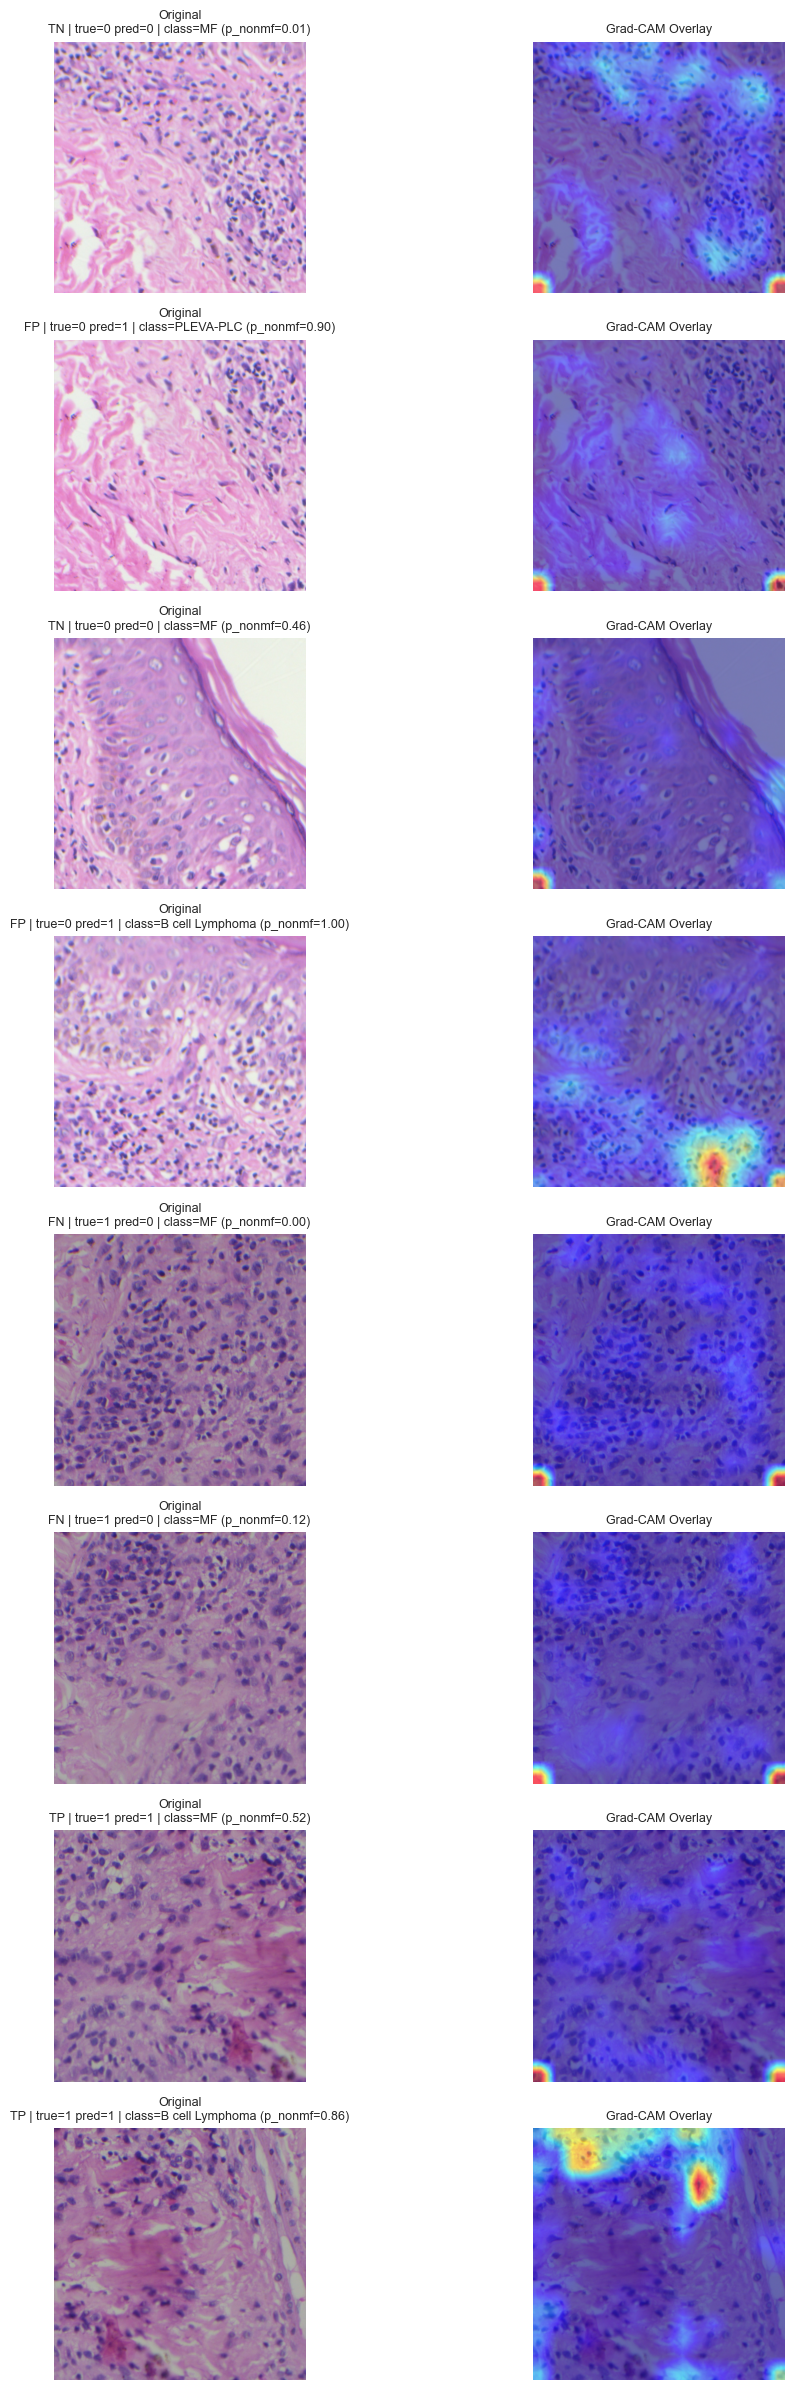

Exception ignored in: <function BaseCAM.__del__ at 0x000002EC7955E5E0>
Traceback (most recent call last):
  File "c:\Users\Mohamed Hazem\anaconda3\envs\dlclass\lib\site-packages\pytorch_grad_cam\base_cam.py", line 212, in __del__
    self.activations_and_grads.release()
AttributeError: 'GradCAM' object has no attribute 'activations_and_grads'
Exception ignored in: <function BaseCAM.__del__ at 0x000002EC7955E5E0>
Traceback (most recent call last):
  File "c:\Users\Mohamed Hazem\anaconda3\envs\dlclass\lib\site-packages\pytorch_grad_cam\base_cam.py", line 212, in __del__
    self.activations_and_grads.release()
AttributeError: 'GradCAM' object has no attribute 'activations_and_grads'


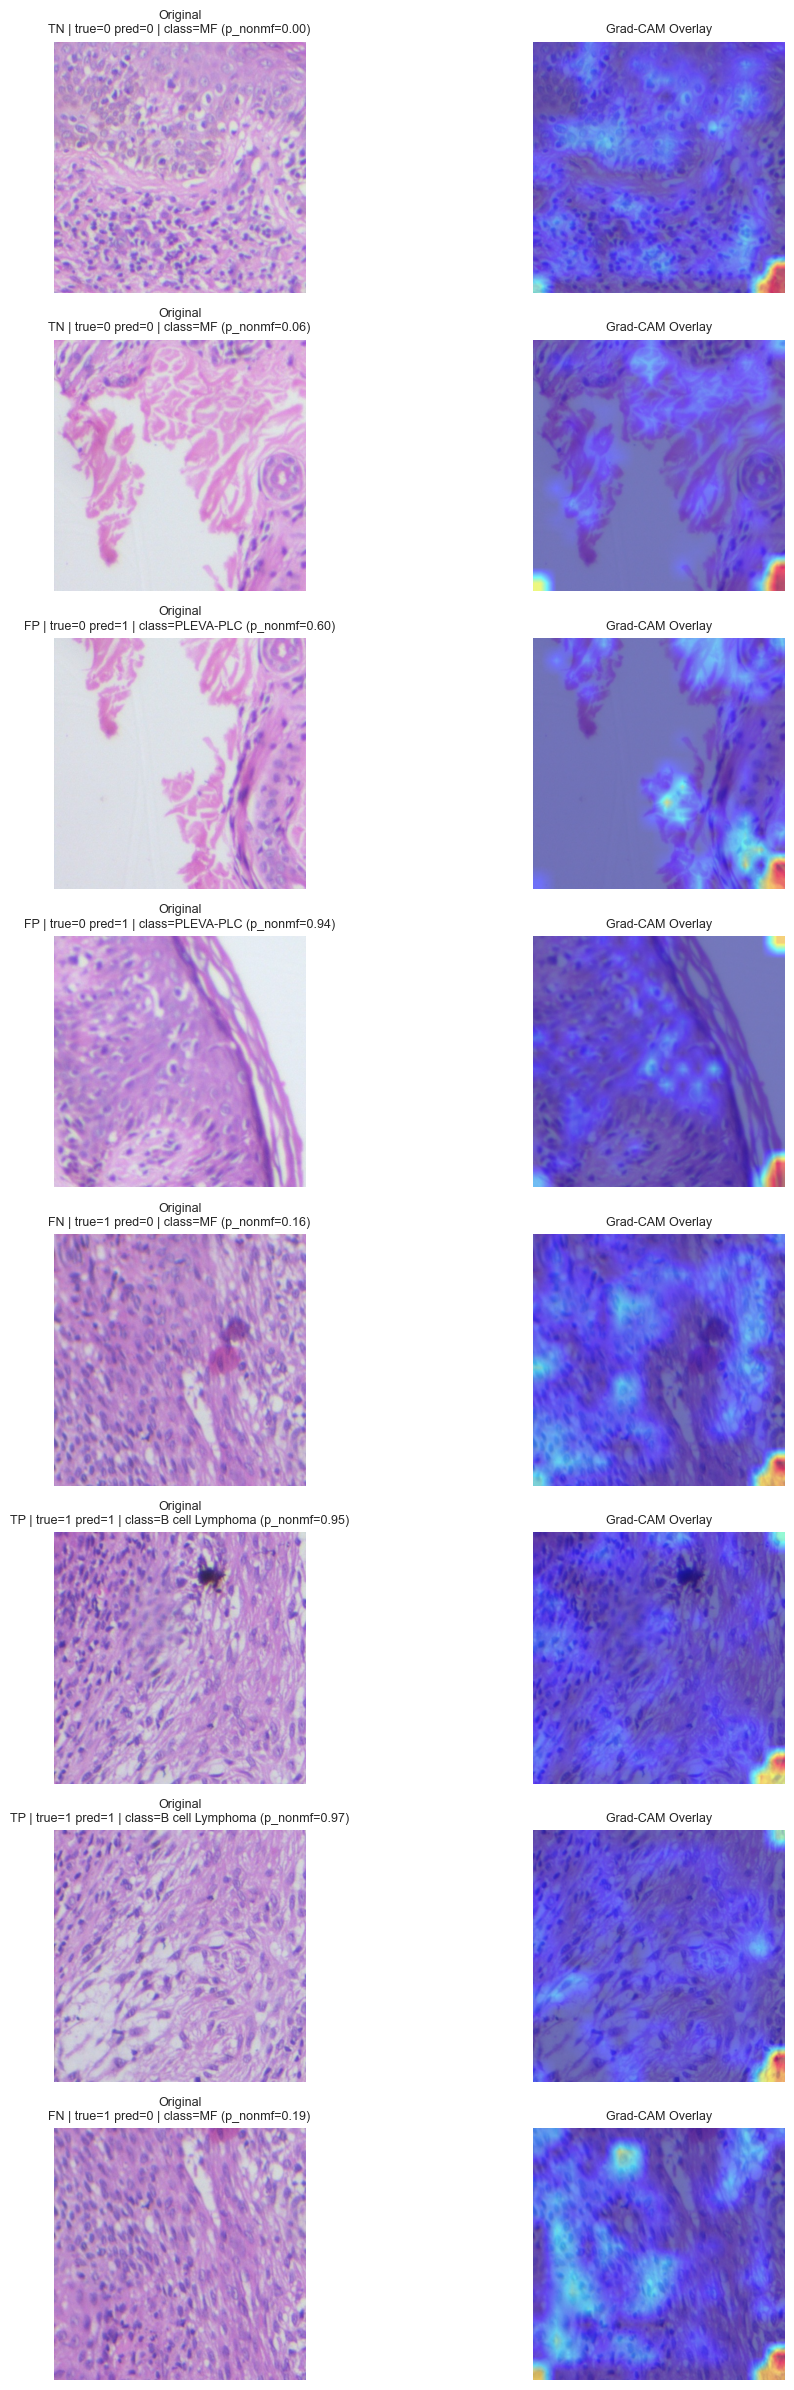

In [25]:
# Cell 11b - Run Grad-CAM visualizations for test loaders
print("\nRunning Grad-CAM visualizations (8 patches each)")
# x20 first (larger patches)
examples_x20 = plot_gradcam_for_binary_patch_errors(model_20, test_loader_20, device, decision_boundary=0.5)
# x10 next
examples_x10 = plot_gradcam_for_binary_patch_errors(model_10, test_loader_10, device, decision_boundary=0.5)

In [12]:
# Cell 11 - The 5-Class Performance Diagnostic (With Threshold Calibration)

print("\n" + "="*80)
print("RUNNING 5-CLASS RAW DIAGNOSTIC")
print("="*80)

def evaluate_5class(model, loader, device, mag, optimal_threshold=0.5):
    model.eval()
    
    dataset_obj = loader.dataset
    try:
        target_names = [dataset_obj.idx2label[i] for i in range(5)]
        mf_idx = dataset_obj.label2idx['MF']
    except:
        target_names = [f"Class {i}" for i in range(5)]
        mf_idx = 0 # Fallback
        
    patch_preds, patch_labels = [], []
    patient_probs = defaultdict(list)
    patient_labels = {}
    
    with torch.no_grad():
        for imgs, labels, sources in tqdm(loader, desc=f"5-Class {mag}"):
            imgs = imgs.to(device)
            outputs = model(imgs)
            probs = F.softmax(outputs, dim=1).cpu().numpy()
            lbls = labels.numpy()
            
            # --- PATCH LEVEL THRESHOLD LOGIC ---
            p_mf = probs[:, mf_idx]
            p_non_mf = 1.0 - p_mf
            
            # Find the highest mimic class (ignoring MF)
            masked_probs = np.copy(probs)
            masked_probs[:, mf_idx] = -1.0 
            non_mf_preds = np.argmax(masked_probs, axis=1)
            
            # If Non-MF sum > threshold, pick the highest mimic. Else, pick MF.
            preds = np.where(p_non_mf > optimal_threshold, non_mf_preds, mf_idx)
            
            patch_preds.extend(preds)
            patch_labels.extend(lbls)
            
            # Group by patient for patient-level aggregation
            patients = [Path(src).parent.parent.name for src in sources]
            for p_name, prob, lbl in zip(patients, probs, lbls):
                patient_probs[p_name].append(prob)
                patient_labels[p_name] = lbl
                
    # --- Calculate Patch Metrics ---
    patch_acc = accuracy_score(patch_labels, patch_preds)
    
    # --- Calculate Patient Metrics (Mean Aggregation with Threshold) ---
    pat_preds, pat_labels = [], []
    for p_name, probs_list in patient_probs.items():
        # Average the 5-class probabilities
        mean_prob = np.mean(probs_list, axis=0)
        
        # --- PATIENT LEVEL THRESHOLD LOGIC ---
        p_mf = mean_prob[mf_idx]
        p_non_mf = 1.0 - p_mf
        
        if p_non_mf > optimal_threshold:
            # Mask MF and find highest mimic
            masked_prob = np.copy(mean_prob)
            masked_prob[mf_idx] = -1.0
            pred = np.argmax(masked_prob)
        else:
            # Trust the MF signal
            pred = mf_idx
            
        pat_preds.append(pred)
        pat_labels.append(patient_labels[p_name])
        
    pat_acc = accuracy_score(pat_labels, pat_preds)
    
    print(f"\n{'='*40}")
    print(f"{mag.upper()} 5-CLASS RESULTS (Threshold: {optimal_threshold})")
    print(f"{'='*40}")
    print(f"Patch-Level Accuracy:   {patch_acc:.4f}")
    print(f"Patient-Level Accuracy: {pat_acc:.4f}")
    
    print("\nPatient-Level Classification Report:")
    print(classification_report(pat_labels, pat_preds, target_names=target_names, zero_division=0))
    
    print("\nPatient-Level 5x5 Confusion Matrix:")
    cm = confusion_matrix(pat_labels, pat_preds)
    
    row_format = "{:>15}" * (len(target_names) + 1)
    print(row_format.format("", *target_names))
    for name, row in zip(target_names, cm):
        print(row_format.format(name, *row))
    print("\n")

# Run x10 with standard threshold
evaluate_5class(model_10, test_loader_10, device, 'x10', optimal_threshold=0.5)

# CRITICAL FIX: Run x20 with the optimal threshold we discovered
evaluate_5class(model_20, test_loader_20, device, 'x20', optimal_threshold=0.8351)


RUNNING 5-CLASS RAW DIAGNOSTIC


5-Class x10:   9%|▉         | 76/803 [00:14<02:20,  5.17it/s]


KeyboardInterrupt: 